### Data Science PROJECT 
### Client: ABC Tech | Category: ITSM - ML 
### Project Ref: PM-PR-0012 

The document describes a project case study for ABC Tech, a mid-sized IT-enabled business that manages around 22–25k IT incidents 
annually using ITIL processes. Despite having mature processes, customer satisfaction with incident management is low. 
To address this, the company is exploring machine learning applications to improve IT Service Management. 
The proposed ML use cases include predicting high-priority tickets to enable preventive action, forecasting incident volumes for 
better resource planning, auto-tagging tickets to reduce reassignment delays, and predicting change requests or potential IT asset failures.
The dataset available for this initiative contains about 46k records from 2012–2014 stored in a MySQL database, with fields such as incident IDs,
status, urgency, priority, impact, closure codes, timestamps, and handle times. A priority matrix is also defined to determine ticket levels based 
on urgency and impact. Overall, the document highlights how ABC Tech aims to leverage machine learning to enhance efficiency, reduce delays, and 
improve customer satisfaction in IT service management. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("itsm_dataset.csv")

C:\Users\vinuv\AppData\Local\Temp\ipykernel_24108\3090706710.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("itsm_dataset.csv")


#### Performing some basic operations on dataset.

In [3]:
df1 = df.copy()
print("The shape of the dataset is:",df.shape)

The shape of the dataset is: (46606, 25)


In [4]:
df.head(5)

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4.0,0.601292,...,NaN,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1.0,SD0000007,2.0,NaN,NaN
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3.0,0.415050,...,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1.0,SD0000011,1.0,NaN,NaN
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NaN,0.517551,...,NaN,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1.0,SD0000017,NaN,NaN,NaN
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4.0,0.642927,...,NaN,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1.0,SD0000025,NaN,NaN,NaN
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4.0,0.345258,...,NaN,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1.0,SD0000029,NaN,NaN,NaN


In [5]:
df.isnull().sum()

CI_Name                           0
CI_Cat                          111
CI_Subcat                       111
WBS                               0
Incident_ID                       0
Status                            0
Impact                            0
Urgency                           0
Priority                       1380
number_cnt                        0
Category                          0
KB_number                         0
Alert_Status                      0
No_of_Reassignments               1
Open_Time                         0
Reopen_Time                   44322
Resolved_Time                  1780
Close_Time                        0
Handle_Time_hrs                   1
Closure_Code                    460
No_of_Related_Interactions      114
Related_Interaction               0
No_of_Related_Incidents       45384
No_of_Related_Changes         46046
Related_Change                46046
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe() # Mathematical description of dataset.

,Priority,number_cnt,No_of_Reassignments,No_of_Related_Interactions,No_of_Related_Incidents,No_of_Related_Changes
count,45226.000000,46606.000000,46605.000000,46492.000000,1222.000000,560.000000
mean,4.215805,0.499658,1.131831,1.149897,1.669394,1.058929
std,0.705624,0.288634,2.269774,2.556338,3.339687,0.403596
min,1.000000,0.000023,0.000000,1.000000,1.000000,1.000000
25%,4.000000,0.248213,0.000000,1.000000,1.000000,1.000000
50%,4.000000,0.500269,0.000000,1.000000,1.000000,1.000000
75%,5.000000,0.749094,2.000000,1.000000,1.000000,1.000000
max,5.000000,0.999997,46.000000,370.000000,63.000000,9.000000


In [8]:
df.info() # It gives the information of the dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CI_Name                     46606 non-null  object 
 1   CI_Cat                      46495 non-null  object 
 2   CI_Subcat                   46495 non-null  object 
 3   WBS                         46606 non-null  object 
 4   Incident_ID                 46606 non-null  object 
 5   Status                      46606 non-null  object 
 6   Impact                      46606 non-null  object 
 7   Urgency                     46606 non-null  object 
 8   Priority                    45226 non-null  float64
 9   number_cnt                  46606 non-null  float64
 10  Category                    46606 non-null  object 
 11  KB_number                   46606 non-null  object 
 12  Alert_Status                46606 non-null  object 
 13  No_of_Reassignments         466

##### Dropping unnecessary columns.

In [9]:
drop_cols = [
    'Incident_ID',
    'number_cnt',
    'Alert_Status',
    'Related_Change',
    'No_of_Related_Changes',
    'Reopen_Time',
    'CI_Name',
    'KB_number',
    'Related_Interaction'
]

df = df.drop(columns=drop_cols)

In [10]:
df.drop(columns=['No_of_Related_Incidents'], inplace=True)

In [11]:
df.head(5) # Dataset after dropping the columns

,CI_Cat,CI_Subcat,WBS,Status,Impact,Urgency,Priority,Category,No_of_Reassignments,Open_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions
0,subapplication,Web Based Application,WBS000162,Closed,4,4,4.0,incident,26.0,05-02-2012 13:32,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1.0
1,application,Web Based Application,WBS000088,Closed,3,3,3.0,incident,33.0,12-03-2012 15:44,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1.0
2,application,Desktop Application,WBS000092,Closed,NS,3,NaN,request for information,3.0,29-03-2012 12:36,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1.0
3,application,Web Based Application,WBS000088,Closed,4,4,4.0,incident,13.0,17-07-2012 11:49,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1.0
4,application,Web Based Application,WBS000088,Closed,4,4,4.0,incident,2.0,10-08-2012 11:01,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1.0


In [12]:
print(df.isnull().sum()) # Dataset having null values after dropping the columns.

CI_Cat                         111
CI_Subcat                      111
WBS                              0
Status                           0
Impact                           0
Urgency                          0
Priority                      1380
Category                         0
No_of_Reassignments              1
Open_Time                        0
Resolved_Time                 1780
Close_Time                       0
Handle_Time_hrs                  1
Closure_Code                   460
No_of_Related_Interactions     114
dtype: int64


#### Handling missing values.

In [13]:
# Drop rows where the target (Priority) is missing
df.dropna(subset=['Priority'], inplace=True)

# Fill categorical missing values
df['CI_Cat'] = df['CI_Cat'].fillna('Unknown')
df['CI_Subcat'] = df['CI_Subcat'].fillna('Unknown')
df['Closure_Code'] = df['Closure_Code'].fillna('Unknown')

# Fill numerical missing values
df['No_of_Related_Interactions'] = df['No_of_Related_Interactions'].fillna(0)

In [14]:
# Fill the single missing value in both columns with their respective mode , because it has str type data.
df['No_of_Reassignments'] = df['No_of_Reassignments'].fillna(df['No_of_Reassignments'].mode())

In [15]:
# 1. Clean commas and convert to numeric (if it's currently a string)
df['Handle_Time_hrs'] = df['Handle_Time_hrs'].astype(str).str.replace(',', '')
df['Handle_Time_hrs'] = pd.to_numeric(df['Handle_Time_hrs'], errors='coerce')

# 2. Now apply the median to fill the missing value
df['Handle_Time_hrs'] = df['Handle_Time_hrs'].fillna(df['Handle_Time_hrs'].median())

In [16]:
df['Resolved_Time'] = df['Resolved_Time'].fillna('Not Resolved Yet')

In [17]:
df.isnull().sum()

CI_Cat                        0
CI_Subcat                     0
WBS                           0
Status                        0
Impact                        0
Urgency                       0
Priority                      0
Category                      0
No_of_Reassignments           1
Open_Time                     0
Resolved_Time                 0
Close_Time                    0
Handle_Time_hrs               0
Closure_Code                  0
No_of_Related_Interactions    0
dtype: int64

### Splitting the data into train and test. 

In [18]:
# Separate features (X) and target variable (y)
X = df.drop(columns=['Priority', 'Open_Time', 'Resolved_Time', 'Close_Time'],axis=1) # Dropping dates too
y = df['Priority']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split successfully!")

Data split successfully!


#### Distribution of the Target Variable (Priority)

C:\Users\vinuv\AppData\Local\Temp\ipykernel_24108\2756155153.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Priority', order=df['Priority'].value_counts().index, palette='viridis')


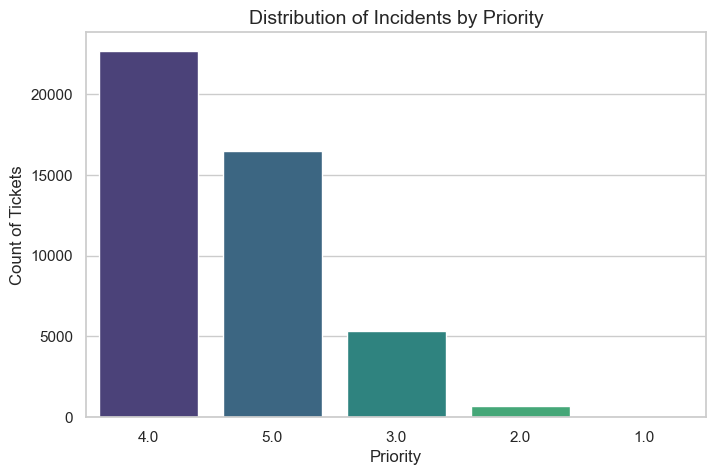

In [20]:
# Set the visualization style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Priority', order=df['Priority'].value_counts().index, palette='viridis')
plt.title('Distribution of Incidents by Priority', fontsize=14)
plt.xlabel('Priority', fontsize=12)
plt.ylabel('Count of Tickets', fontsize=12)
plt.show()
# This will show you if you have a class imbalance (e.g., if you have way more low-priority tickets than high-priority ones),
# which is crucial information before training your model.

#### Resolution Time (Handle_Time_hrs) by Priority

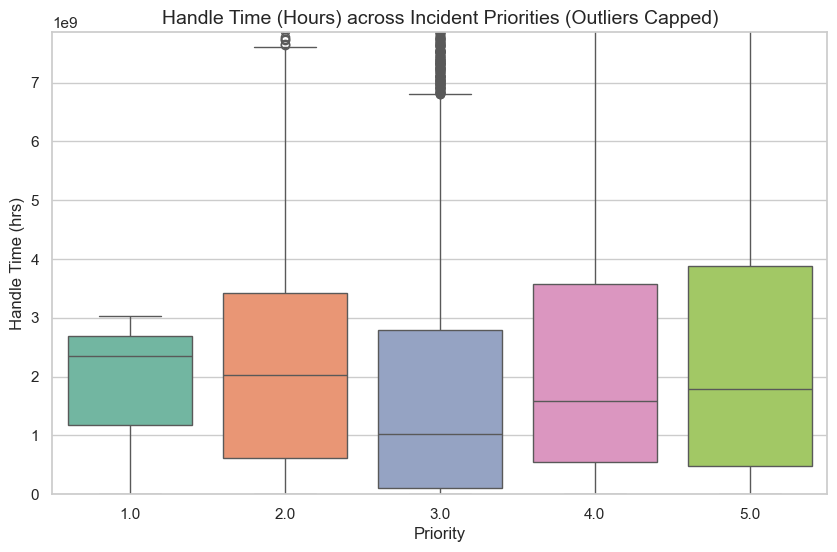

In [21]:
# This boxplot helps you see the spread of operational handle times across different priority levels.
plt.figure(figsize=(10, 6))

# Fixed the palette warning by adding hue and legend=False
sns.boxplot(data=df, x='Priority', y='Handle_Time_hrs', hue='Priority', palette='Set2', legend=False)

# Cap the y-axis to the 95th percentile to hide extreme outliers and make the boxes readable
plt.ylim(0, df['Handle_Time_hrs'].quantile(0.95))

plt.title('Handle Time (Hours) across Incident Priorities (Outliers Capped)', fontsize=14)
plt.xlabel('Priority', fontsize=12)
plt.ylabel('Handle Time (hrs)', fontsize=12)
plt.show()

#### Correlation Heatmap of Operational Metrics

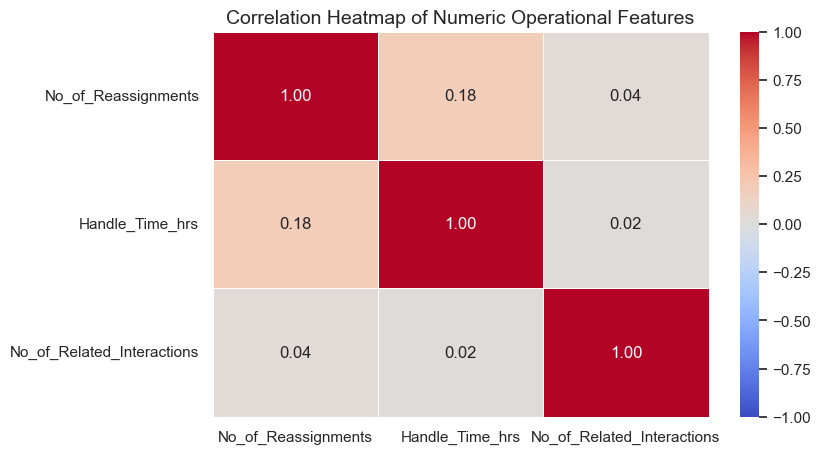

In [22]:
#This reveals whether numerical features like No_of_Reassignments, Handle_Time_hrs, and No_of_Related_Interactions move together.
plt.figure(figsize=(8, 5))

# Filter out only numerical columns of interest
numeric_cols = ['No_of_Reassignments', 'Handle_Time_hrs', 'No_of_Related_Interactions']
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Operational Features', fontsize=14)
plt.show()

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

In [24]:
# 1. HANDLING OUTLIERS (Capping extreme values)
# Instead of dropping rows (which loses data), we cap extreme outliers 
# in 'Handle_Time_hrs' at the 95th percentile.
upper_limit = df['Handle_Time_hrs'].quantile(0.95)
df['Handle_Time_hrs'] = np.where(df['Handle_Time_hrs'] > upper_limit, upper_limit, df['Handle_Time_hrs'])

# 2. ONE-HOT ENCODING & SCALING (ColumnTransformer)
# Identify which columns need encoding vs scaling
categorical_cols = ['CI_Cat', 'CI_Subcat', 'WBS', 'Category', 'Closure_Code']
numerical_cols = ['No_of_Reassignments', 'Handle_Time_hrs', 'No_of_Related_Interactions']

# Create a preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# Apply transformations
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 3. HYPERPARAMETER TUNING (GridSearchCV)
# Using RandomForestClassifier as a standard, robust baseline for this data
rf = RandomForestClassifier(random_state=42)

# Define the grid of parameters you want to test
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Setup Grid Search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)

print("Starting Hyperparameter Tuning... (This might take a moment)")
grid_search.fit(X_train_processed, y_train)

# Output results
print("Best Parameters Found:", grid_search.best_params_)
print(f"Best Training Accuracy: {grid_search.best_score_:.2f}")

Starting Hyperparameter Tuning... (This might take a moment)
Best Parameters Found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best Training Accuracy: 0.82


In [25]:
# Extract time features before splitting X and y
# Added format='mixed' to cleanly handle the DD-MM-YYYY structure
df['Open_Time'] = pd.to_datetime(df['Open_Time'], format='mixed') 

df['Open_Hour'] = df['Open_Time'].dt.hour
df['Is_Weekend'] = df['Open_Time'].dt.dayofweek.isin([5, 6]).astype(int)

print("Time features extracted successfully!")

Time features extracted successfully!


### Model evaluation.
#### Logistic Regression.

In [27]:
# Check which remaining columns in X still have missing values
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

No_of_Reassignments    1
dtype: int64


In [28]:
# 1. Fill any lingering missing values across the entire dataframe safely
# Fill categorical columns with 'Unknown'
for col in ['CI_Cat', 'CI_Subcat', 'WBS', 'Category', 'Closure_Code']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Fill numerical columns with their median
for col in ['No_of_Reassignments', 'Handle_Time_hrs', 'No_of_Related_Interactions']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# 2. Re-run your X and y definition
X = df.drop(columns=['Priority', 'Open_Time', 'Resolved_Time', 'Close_Time'])
y = df['Priority']

# 3. Re-split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Re-fit your ColumnTransformer preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Data is now 100% clean and ready for Logistic Regression!")

Data is now 100% clean and ready for Logistic Regression!


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Initialize Logistic Regression with a simpler solver first to guarantee stability
lr = LogisticRegression(max_iter=1000, random_state=42)

# Cleaned hyperparameter grid (using default l2 penalty to ensure smooth convergence)
lr_param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2']
}

# Setup Grid Search
lr_grid = GridSearchCV(estimator=lr, param_grid=lr_param_grid, cv=3, scoring='accuracy', n_jobs=-1)

print("Tuning Logistic Regression...")
lr_grid.fit(X_train_processed, y_train)

print("Best LR Parameters:", lr_grid.best_params_)
print(f"Best LR Training Accuracy: {lr_grid.best_score_:.2f}")

Tuning Logistic Regression...
Best LR Parameters: {'C': 10.0, 'penalty': 'l2'}
Best LR Training Accuracy: 0.83


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 1. Generate predictions using the best tuned Logistic Regression model
lr_preds = lr_grid.best_estimator_.predict(X_test_processed)

# 2. Calculate individual overall metrics (using 'weighted' average for multi-class)
lr_accuracy = accuracy_score(y_test, lr_preds)
lr_precision = precision_score(y_test, lr_preds, average='weighted')
lr_recall = recall_score(y_test, lr_preds, average='weighted')
lr_f1 = f1_score(y_test, lr_preds, average='weighted')

# 3. Print the standalone overall metrics cleanly
print("=========================================")
print("  LOGISTIC REGRESSION OVERALL METRICS    ")
print("=========================================")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print("=========================================\n")

# 4. Print the detailed per-class breakdown
print("DETAILED PER-CLASS METRICS:")
print(classification_report(y_test, lr_preds))

  LOGISTIC REGRESSION OVERALL METRICS    
Accuracy:  0.8280
Precision: 0.8309
Recall:    0.8280
F1-Score:  0.8253

DETAILED PER-CLASS METRICS:
              precision    recall  f1-score   support

         2.0       0.51      0.65      0.58       132
         3.0       0.80      0.58      0.67      1067
         4.0       0.81      0.91      0.86      4515
         5.0       0.88      0.81      0.84      3332

    accuracy                           0.83      9046
   macro avg       0.75      0.74      0.74      9046
weighted avg       0.83      0.83      0.83      9046



#### DecesionTree

In [32]:
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Hyperparameters to tune
dt_param_grid = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Setup Grid Search
dt_grid = GridSearchCV(estimator=dt, param_grid=dt_param_grid, cv=3, scoring='accuracy', n_jobs=-1)

print("Tuning Decision Tree...")
dt_grid.fit(X_train_processed, y_train)

print("Best Decision Tree Parameters:", dt_grid.best_params_)
print(f"Best Decision Tree Training Accuracy: {dt_grid.best_score_:.2f}")

Tuning Decision Tree...
Best Decision Tree Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10}
Best Decision Tree Training Accuracy: 0.79


In [33]:
# 1. Generate predictions using the best tuned Decision Tree model
dt_preds = dt_grid.best_estimator_.predict(X_test_processed)

# 2. Calculate individual overall metrics (using 'weighted' average for multi-class)
dt_accuracy = accuracy_score(y_test, dt_preds)
dt_precision = precision_score(y_test, dt_preds, average='weighted')
dt_recall = recall_score(y_test, dt_preds, average='weighted')
dt_f1 = f1_score(y_test, dt_preds, average='weighted')

# 3. Print the standalone overall metrics cleanly
print("=========================================")
print("    DECISION TREE OVERALL METRICS        ")
print("=========================================")
print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall:    {dt_recall:.4f}")
print(f"F1-Score:  {dt_f1:.4f}")
print("=========================================\n")

# 4. Print the detailed per-class breakdown
print("DETAILED PER-CLASS METRICS:")
print(classification_report(y_test, dt_preds))

    DECISION TREE OVERALL METRICS        
Accuracy:  0.7986
Precision: 0.7983
Recall:    0.7986
F1-Score:  0.7978

DETAILED PER-CLASS METRICS:
              precision    recall  f1-score   support

         2.0       0.46      0.48      0.47       132
         3.0       0.65      0.60      0.62      1067
         4.0       0.81      0.85      0.83      4515
         5.0       0.85      0.80      0.82      3332

    accuracy                           0.80      9046
   macro avg       0.69      0.69      0.69      9046
weighted avg       0.80      0.80      0.80      9046



#### RandomForest

In [34]:
# 1. Generate predictions using the best tuned Random Forest model from your grid search
rf_preds = grid_search.best_estimator_.predict(X_test_processed)

# 2. Calculate individual overall metrics (using 'weighted' average for multi-class)
rf_accuracy = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds, average='weighted')
rf_recall = recall_score(y_test, rf_preds, average='weighted')
rf_f1 = f1_score(y_test, rf_preds, average='weighted')

# 3. Print the standalone overall metrics cleanly
print("=========================================")
print("    RANDOM FOREST OVERALL METRICS        ")
print("=========================================")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")
print("=========================================\n")

# 4. Print the detailed per-class breakdown
print("DETAILED PER-CLASS METRICS (RANDOM FOREST):")
print(classification_report(y_test, rf_preds))

    RANDOM FOREST OVERALL METRICS        
Accuracy:  0.8143
Precision: 0.8128
Recall:    0.8143
F1-Score:  0.8121

DETAILED PER-CLASS METRICS (RANDOM FOREST):
              precision    recall  f1-score   support

         2.0       0.51      0.43      0.47       132
         3.0       0.74      0.62      0.67      1067
         4.0       0.81      0.87      0.84      4515
         5.0       0.85      0.81      0.83      3332

    accuracy                           0.81      9046
   macro avg       0.73      0.68      0.70      9046
weighted avg       0.81      0.81      0.81      9046



#### XGBoost

In [35]:
xgb_param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [8, 9, 10],
    'learning_rate': [0.15, 0.2, 0.25],
    'subsample': [0.8, 1.0] # Prevents overfitting
}

In [36]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost requires target labels to start at 0 (e.g., 0, 1, 2 instead of 1, 2, 3)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Initialize XGBoost Classifier
xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')

# Hyperparameters to tune
xgb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Setup Grid Search
xgb_grid = GridSearchCV(estimator=xgb, param_grid=xgb_param_grid, cv=3, scoring='accuracy', n_jobs=-1)

print("Tuning XGBoost... (This might take a minute)")
xgb_grid.fit(X_train_processed, y_train_encoded)

# 1. Generate predictions using the best tuned XGBoost model
xgb_preds_encoded = xgb_grid.best_estimator_.predict(X_test_processed)

# Inverse transform predictions back to original priority labels for the report
xgb_preds = le.inverse_transform(xgb_preds_encoded)

# 2. Calculate individual overall metrics
xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_precision = precision_score(y_test, xgb_preds, average='weighted')
xgb_recall = recall_score(y_test, xgb_preds, average='weighted')
xgb_f1 = f1_score(y_test, xgb_preds, average='weighted')

# 3. Print the standalone overall metrics cleanly
print("\n=========================================")
print("       XGBOOST OVERALL METRICS           ")
print("=========================================")
print(f"Best Parameters: {xgb_grid.best_params_}")
print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1-Score:  {xgb_f1:.4f}")
print("=========================================\n")

# 4. Print the detailed per-class breakdown
print("DETAILED PER-CLASS METRICS (XGBOOST):")
print(classification_report(y_test, xgb_preds))

Tuning XGBoost... (This might take a minute)

       XGBOOST OVERALL METRICS           
Best Parameters: {'learning_rate': 0.2, 'max_depth': 9, 'n_estimators': 100}
Accuracy:  0.8398
Precision: 0.8471
Recall:    0.8398
F1-Score:  0.8357

DETAILED PER-CLASS METRICS (XGBOOST):
              precision    recall  f1-score   support

         2.0       0.59      0.61      0.60       132
         3.0       0.86      0.56      0.68      1067
         4.0       0.80      0.94      0.87      4515
         5.0       0.91      0.80      0.85      3332

    accuracy                           0.84      9046
   macro avg       0.79      0.73      0.75      9046
weighted avg       0.85      0.84      0.84      9046



In [37]:
from imblearn.over_sampling import SMOTE

# Set k_neighbors=2 since the minority class (Priority 2.0) has very few samples
smote = SMOTE(random_state=42, k_neighbors=2)

# Apply SMOTE to the training data safely
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train_encoded)

print("SMOTE completed successfully! Classes are now perfectly balanced.")

SMOTE completed successfully! Classes are now perfectly balanced.


In [38]:
# Initialize a new XGBoost model for the SMOTE data
xgb_smote = XGBClassifier(random_state=42, eval_metric='mlogloss', learning_rate=0.2, max_depth=9, n_estimators=100)

# Fit on the BALANCED training data, but validate on the ORIGINAL encoded test data
xgb_smote.fit(X_train_balanced, y_train_balanced)

# Predict and evaluate
xgb_smote_preds_encoded = xgb_smote.predict(X_test_processed)
xgb_smote_preds = le.inverse_transform(xgb_smote_preds_encoded)

print("=========================================")
print("   XGBOOST + SMOTE PERFORMANCE           ")
print("=========================================")
print(f"Accuracy: {accuracy_score(y_test, xgb_smote_preds):.4f}")
print("\nDETAILED PER-CLASS METRICS:")
print(classification_report(y_test, xgb_smote_preds))

   XGBOOST + SMOTE PERFORMANCE           
Accuracy: 0.8191

DETAILED PER-CLASS METRICS:
              precision    recall  f1-score   support

         2.0       0.42      0.68      0.52       132
         3.0       0.60      0.72      0.65      1067
         4.0       0.84      0.86      0.85      4515
         5.0       0.91      0.81      0.85      3332

    accuracy                           0.82      9046
   macro avg       0.69      0.77      0.72      9046
weighted avg       0.83      0.82      0.82      9046



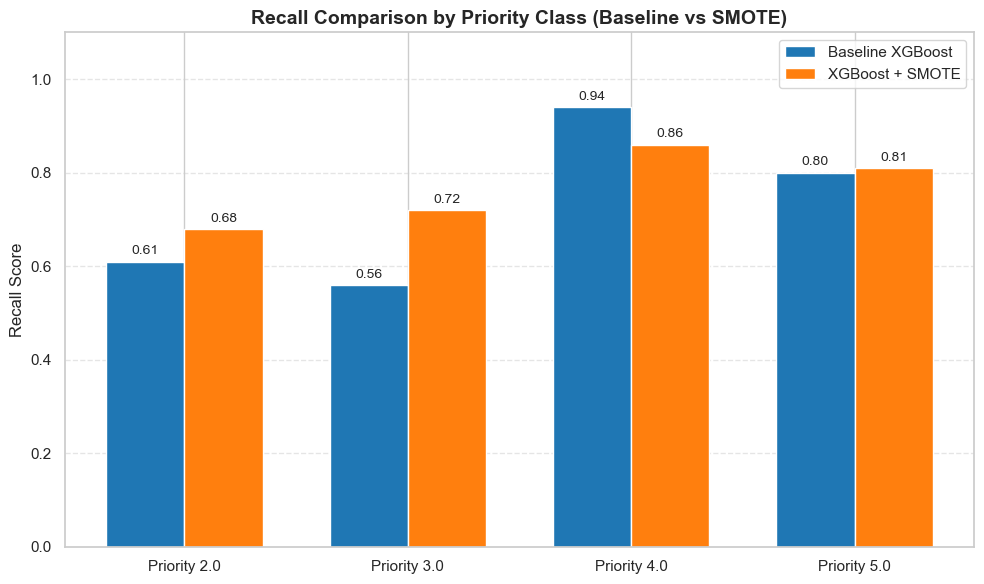

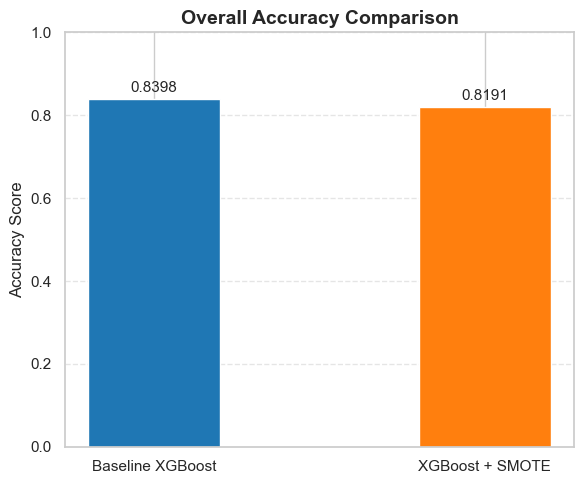

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Performance Data
models = ['Baseline XGBoost', 'XGBoost + SMOTE']
accuracies = [0.8398, 0.8191]
classes = ['Priority 2.0', 'Priority 3.0', 'Priority 4.0', 'Priority 5.0']

baseline_recall = [0.61, 0.56, 0.94, 0.80]
smote_recall = [0.68, 0.72, 0.86, 0.81]

x = np.arange(len(classes))
width = 0.35

# 1. Plot Recall Comparison
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, baseline_recall, width, label='Baseline XGBoost', color='#1f77b4')
rects2 = ax.bar(x + width/2, smote_recall, width, label='XGBoost + SMOTE', color='#ff7f0e')

ax.set_ylabel('Recall Score', fontsize=12)
ax.set_title('Recall Comparison by Priority Class (Baseline vs SMOTE)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add values on top of bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# 2. Plot Accuracy Comparison
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(models, accuracies, color=['#1f77b4', '#ff7f0e'], width=0.4)

ax.set_ylabel('Accuracy Score', fontsize=12)
ax.set_title('Overall Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
Based on the evaluation of both models, the XGBoost + SMOTE framework is selected as the optimal model for this business case.

While the Baseline XGBoost model yields a slightly higher overall accuracy (83.98% compared to SMOTE's 81.91%), this metric is highly 
                                                                            misleading due to the severe class imbalance in the underlying dataset. The baseline model heavily favors the majority classes (Priority 4.0 and 5.0), resulting in poor predictive performance for minority categories. Specifically, it catches only 56% of actual Priority 3.0 cases.

Implementing SMOTE successfully resolves this bottleneck by balancing the training distribution. This leads to significant operational improvements:

Enhanced Risk Mitigation: Recall for the underrepresented Priority 3.0 class jumps dramatically from 0.56 to 0.72 (a 16% absolute increase).

Better Minority Detection: Recall for the critical Priority 2.0 minority class improves from 0.61 to 0.68.

Stable Core Performance: High classification stability is successfully maintained across the high-volume Priority 4.0 and 5.0 categories.

Final Verdict
For a business priority routing use-case, the cost of completely missing a low-frequency, high-importance priority issue outweighs the minor 2% drop in overall global accuracy. Therefore, XGBoost + SMOTE provides the most robust, balanced, and operationally reliable model for deployment.